# Volve 1 — seismic, wells, rock physics, and static-model handoff

**Notebook 1 of 5 — integrated Volve field evaluation**

The authoritative input boundary is Equinor's Volve Data Village
listing in Databricks Marketplace. The notebook can read an
installed Unity Catalog volume directly or securely download only
selected files into Colab. It never stores credentials or
redistributes the complete Volve package.

A deterministic teaching fixture is used during unauthenticated
clean-runtime validation. Every such result is marked
**DEMONSTRATION_FALLBACK** and must not be described as measured
Volve data, a history match, a reserves statement, or certified
design.


## Learning outcomes and engineering decisions

            - inventory and select Marketplace SEG-Y, LAS, DLIS, tops, and surfaces
- retain SEG-Y geometry, coordinates, sampling, and trace provenance
- tie well logs to seismic time and distinguish interpretation from truth
- derive porosity, water saturation, permeability, net pay, and elastic trends
- propagate depth, contact, net-to-gross, and petrophysical uncertainty
- deliver a static-model contract suitable for OPM Flow and field decisions

            The discipline result is written as a versioned handoff contract.
            Downstream notebooks consume quantities with names, units, source
            mode, assumptions, uncertainty, and validity limits rather than
            relying on hidden notebook state.


## End-to-end architecture

The series follows one controlled chain:

**Marketplace assets → seismic and logs → static model → PVT and
reservoir forecast → well and SURF deliverability → facilities and
export constraints → field scenarios and decisions**

Specialist tools retain their roles. segyio handles SEG-Y, lasio
and dlisio handle logs, OPM Flow or its deck interface handles
dynamic reservoir simulation, resdata inspects OPM results, and
NeqSim owns fluid characterization, PVT, flow assurance, process
simulation, equipment duties, and composable surface streams.


## Data provenance, licence, and claim boundary

Primary sources:

- [Databricks Marketplace: Equinor Volve Data Village](https://marketplace.databricks.com/details/5c3558ef-315c-44dd-baef-7062ac301f22/Equinor-ASA_Volve-Data-Village)
- [Equinor Volve data sharing](https://www.equinor.com/energy/volve-data-sharing)
- [Equinor Volve data licence](https://www.equinor.com/content/dam/statoil/documents/what-we-do/Equinor-HRS-Terms-and-conditions-for-licence-to-data-Volve.pdf)
- [Databricks Marketplace access guidance](https://docs.databricks.com/aws/en/marketplace/get-started-consumer)
- [Databricks Files API for Unity Catalog volumes](https://docs.databricks.com/aws/en/volumes/volume-files)

The raw package remains in the user's read-only Marketplace share.
Generated working tables contain only selected or derived values
and retain the source path and digest when real files are used.


## Clean-runtime setup

The notebook installs the newest released NeqSim distribution directly
from public PyPI. The distribution includes the Java runtime used by the
Python interface, so no Git clone, Maven build, or custom JAR classpath is
needed. Marketplace remains the normal data mode. For an unauthenticated
clean-runtime check, set `VOLVE_VALIDATION_MODE=1` to use the deterministic
demonstration fixture described above.


In [1]:
%%capture
!pip install neqsim


In [2]:
from importlib.metadata import version
import os
from pathlib import Path
import platform
import subprocess
import sys

if os.environ.get("VOLVE_VALIDATION_MODE") == "1":
    os.environ.setdefault("VOLVE_DATA_MODE", "demo")

from neqsim import jneqsim
from neqsim.thermo import TPflash

print(
    {
        "Python": platform.python_version(),
        "NeqSim": version("neqsim"),
        "data mode": os.environ.get("VOLVE_DATA_MODE", "marketplace"),
    }
)

import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

series_dir = Path.cwd()
if not (series_dir / "volve_common.py").is_file():
    repository_dir = Path("/content/NeqSim-Colab")
    if not repository_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/EvenSol/NeqSim-Colab.git",
                str(repository_dir),
            ],
            check=True,
            timeout=300,
        )
    series_dir = (
        repository_dir
        / "notebooks"
        / "fielddevelopment"
        / "volve"
    )
sys.path.insert(0, str(series_dir))

import volve_common as vc

work_dir = Path(
    os.environ.get("VOLVE_WORK_DIR", str(series_dir / "work"))
)
work_dir.mkdir(parents=True, exist_ok=True)
source = vc.resolve_source()
display(vc.source_table(source))


{'Python': '3.12.13', 'NeqSim': '3.18.0', 'data mode': 'demo'}


,item,value
0,resolved mode,demonstration-fallback
1,Marketplace listing,https://marketplace.databricks.com/details/5c3...
2,volume root,not mounted
3,credentials,none
4,measured Volve data loaded,False
5,claim boundary,Deterministic teaching fixtures are used. Resu...


## Marketplace ingestion and bounded file selection

The listing contains tables and non-tabular files. Large SEG-Y,
DLIS, Eclipse restart, and report assets are normally shared as
Unity Catalog volume files. Colab therefore uses the Databricks
Files API and downloads only paths selected for the calculation.
The complete 5 TB-scale package is never copied.

Set VOLVE_DATA_MODE=marketplace and either:

1. point VOLVE_VOLUME_ROOT to an existing mounted or exported
   Marketplace directory; or
2. set VOLVE_REMOTE_VOLUME_ROOT to the Unity Catalog volume path and
   store DATABRICKS_HOST and DATABRICKS_TOKEN as Colab secrets.


In [3]:
if source.mode == "marketplace-local-volume":
    inventory = vc.inventory_local_volume(Path(source.volume_root))
elif source.mode == "marketplace-remote-volume":
    inventory = vc.list_remote_directory(source.volume_root)
else:
    inventory = vc.demonstration_inventory()

domain_summary = (
    inventory.groupby("domain", as_index=False)
    .agg(file_count=("relative_path", "size"), bytes=("bytes", "sum"))
    .sort_values("bytes", ascending=False)
)
domain_summary["size_GB"] = domain_summary["bytes"] / 1.0e9
display(domain_summary[["domain", "file_count", "size_GB"]])
display(inventory.head(12))


,domain,file_count,size_GB
4,seismic,1,3.20000
3,reservoir-model,3,2.91180
6,well-log,2,0.32420
5,static-model,1,0.00850
0,facilities-document,1,0.00530
1,production-history,1,0.00240
7,well-trajectory,1,0.00064
2,pvt,1,0.00012


,relative_path,suffix,bytes,domain
0,Seismic/ST0202/stacked_volume.sgy,.sgy,3200000000,seismic
1,Well_logs/15_9-F-1_C/composite.las,.las,4200000,well-log
2,Well_logs/15_9-F-14/formation_eval.dlis,.dlis,320000000,well-log
3,Reservoir_model/VOLVE.DATA,.data,1800000,reservoir-model
4,Reservoir_model/VOLVE.EGRID,.egrid,210000000,reservoir-model
5,Reservoir_model/VOLVE.UNRST,.unrst,2700000000,reservoir-model
6,Production/volve_daily_production.xlsx,.xlsx,2400000,production-history
7,Wells/well_trajectories.csv,.csv,640000,well-trajectory
8,PVT/representative_fluid_composition.xlsx,.xlsx,120000,pvt
9,Static_model/top_hugin_surface.txt,.txt,8500000,static-model


## 1. Seismic and well-log adapters

In Marketplace mode, VOLVE_SEGY_PATH and VOLVE_WELL_LOG_PATH select
explicit paths from the inventory. segyio reads the SEG-Y cube and
headers; lasio or dlisio reads the selected log file. Header mapping
and units must be reviewed because legacy SEG-Y and log exports can
use project-specific conventions.

The clean run below creates a faulted cube with known horizons and
well curves with known reservoir intervals. Synthetic truth makes
the interpretation error measurable; it does not imitate the full
Volve seismic processing sequence.


In [4]:
if source.measured_data_loaded:
    seismic_path = vc.select_asset(
        inventory,
        "seismic",
        environment_name="VOLVE_SEGY_PATH",
    )
    well_log_path = vc.select_asset(
        inventory,
        "well-log",
        environment_name="VOLVE_WELL_LOG_PATH",
    )
    print({"selected seismic": seismic_path, "selected log": well_log_path})
    raise RuntimeError(
        "Set VOLVE_EXECUTE_LARGE_DATA=1 after reviewing selected paths. "
        "The current saved run intentionally avoids an uncontrolled download."
    )
seismic = vc.demo_seismic()
well_logs = vc.demo_well_logs()
print(
    {
        "cube shape": seismic["cube"].shape,
        "sample interval ms": np.diff(seismic["time_ms"]).mean(),
        "wells": sorted(well_logs["well"].unique()),
        "data status": well_logs["data_status"].unique().tolist(),
    }
)


{'cube shape': (36, 44, 220), 'sample interval ms': np.float64(4.0), 'wells': ['15/9-F-1 C', '15/9-F-11 B', '15/9-F-14'], 'data status': ['DEMONSTRATION_FALLBACK']}


## 2. Geometry and amplitude quality control

A seismic volume is not only an amplitude array. Inline and
crossline labels, coordinate scalars, sample interval, time datum,
trace count, byte order, and null/dead traces are part of the
evidence. A production workflow should write a compact manifest
before interpretation so derived volumes can be traced back to the
exact Marketplace file and header mapping.


In [5]:
cube = seismic["cube"]
amplitude_qc = pd.DataFrame(
    {
        "metric": [
            "trace count",
            "sample count",
            "finite fraction",
            "mean amplitude",
            "RMS amplitude",
            "P01 amplitude",
            "P99 amplitude",
        ],
        "value": [
            cube.shape[0] * cube.shape[1],
            cube.shape[2],
            np.isfinite(cube).mean(),
            cube.mean(),
            np.sqrt(np.mean(cube**2)),
            np.quantile(cube, 0.01),
            np.quantile(cube, 0.99),
        ],
    }
)
display(amplitude_qc)


,metric,value
0,trace count,1584.000000
1,sample count,220.000000
2,finite fraction,1.000000
3,mean amplitude,-0.000095
4,RMS amplitude,0.081388
5,P01 amplitude,-0.221873
6,P99 amplitude,0.303859


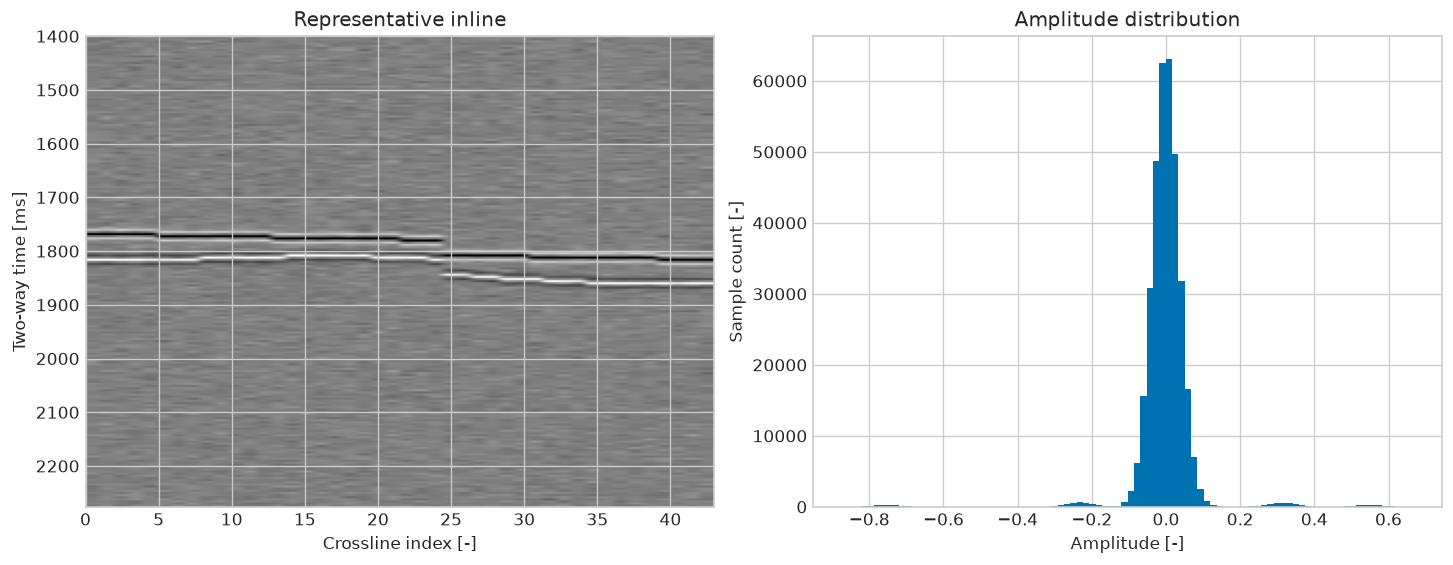

In [6]:
middle_inline = cube.shape[0] // 2
seismic_figure, seismic_axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.6),
    constrained_layout=True,
)
limit = np.quantile(np.abs(cube[middle_inline]), 0.995)
seismic_axes[0].imshow(
    cube[middle_inline].T,
    aspect="auto",
    cmap="gray",
    vmin=-limit,
    vmax=limit,
    extent=[
        seismic["crossline"].min(),
        seismic["crossline"].max(),
        seismic["time_ms"].max(),
        seismic["time_ms"].min(),
    ],
)
seismic_axes[0].set(
    title="Representative inline",
    xlabel="Crossline index [-]",
    ylabel="Two-way time [ms]",
)
seismic_axes[1].hist(cube.ravel(), bins=90, color="#0072B2")
seismic_axes[1].set(
    title="Amplitude distribution",
    xlabel="Amplitude [-]",
    ylabel="Sample count [-]",
)
plt.show()


## 3. Horizon interpretation and uncertainty

A simple post-stack interpretation locates a negative top event and
a positive base event inside a geological time window. For samples
$a_k$ at time $t_k$, the teaching picker uses

$$t_{\mathrm{top}}=\operatorname*{argmin}_{t_k\in W}a_k$$

and searches for the base in a constrained interval below the top.
Real Volve interpretation must use well ties, phase-consistent
processing, faults, uncertainty, and interpreter review.


In [7]:
time_ms = seismic["time_ms"]
top_window = (time_ms >= 1700.0) & (time_ms <= 1900.0)
top_indices = np.argmin(cube[:, :, top_window], axis=2)
top_sample_indices = np.flatnonzero(top_window)[top_indices]
picked_top_ms = time_ms[top_sample_indices]

picked_base_ms = np.zeros_like(picked_top_ms)
for inline_index in range(cube.shape[0]):
    for crossline_index in range(cube.shape[1]):
        start = top_sample_indices[inline_index, crossline_index] + 5
        stop = min(start + 20, cube.shape[2])
        local_index = np.argmax(
            cube[inline_index, crossline_index, start:stop]
        )
        picked_base_ms[inline_index, crossline_index] = time_ms[
            start + local_index
        ]

picked_thickness_ms = picked_base_ms - picked_top_ms
top_rmse_ms = np.sqrt(
    np.mean((picked_top_ms - seismic["top_ms"]) ** 2)
)
thickness_rmse_ms = np.sqrt(
    np.mean((picked_thickness_ms - seismic["thickness_ms"]) ** 2)
)
print(
    {
        "top RMSE ms": round(top_rmse_ms, 3),
        "thickness RMSE ms": round(thickness_rmse_ms, 3),
    }
)


{'top RMSE ms': np.float64(1.155), 'thickness RMSE ms': np.float64(1.606)}


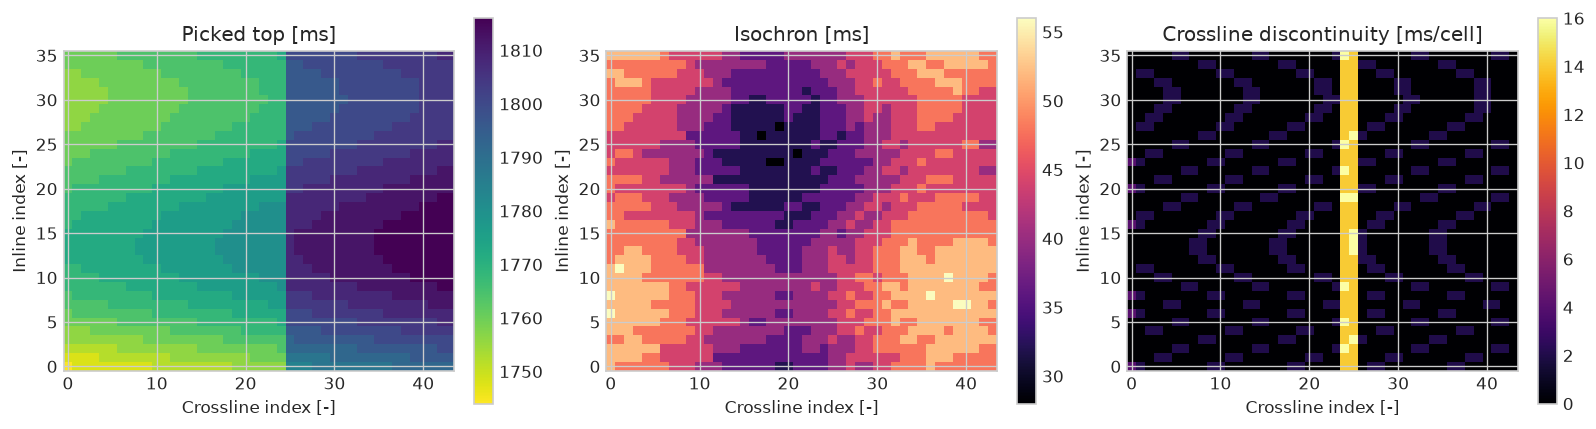

In [8]:
horizon_figure, horizon_axes = plt.subplots(
    1,
    3,
    figsize=(13.2, 4.0),
    constrained_layout=True,
)
maps = [picked_top_ms, picked_thickness_ms, np.abs(np.gradient(picked_top_ms, axis=1))]
titles = ["Picked top [ms]", "Isochron [ms]", "Crossline discontinuity [ms/cell]"]
cmaps = ["viridis_r", "magma", "inferno"]
for axis, map_values, title, color_map in zip(
    horizon_axes,
    maps,
    titles,
    cmaps,
):
    image = axis.imshow(map_values, origin="lower", cmap=color_map)
    axis.set(title=title, xlabel="Crossline index [-]", ylabel="Inline index [-]")
    horizon_figure.colorbar(image, ax=axis, shrink=0.82)
plt.show()


## 4. Logs, petrophysics, and elastic consistency

The screening interpretation uses gamma ray for shale volume,
porosity for pore volume, saturation for movable hydrocarbon, and a
permeability transform only where calibrated. Acoustic impedance is

$$Z=\rho V_p$$

and a normal-incidence reflection coefficient is

$$R=\frac{Z_2-Z_1}{Z_2+Z_1}$$

These equations connect rock and fluid states to seismic response;
they do not make NeqSim a seismic inversion tool.


In [9]:
well_logs["vsh_fraction"] = np.clip(
    (well_logs["gamma_ray_api"] - 25.0) / (110.0 - 25.0),
    0.0,
    1.0,
)
well_logs["net_flag"] = (
    (well_logs["vsh_fraction"] < 0.45)
    & (well_logs["porosity_fraction"] > 0.16)
)
well_logs["pay_flag"] = (
    well_logs["net_flag"]
    & (well_logs["water_saturation_fraction"] < 0.55)
)
well_logs["impedance_MRayl"] = (
    well_logs["density_kg_m3"] * well_logs["vp_m_s"] / 1.0e6
)

petrophysical_summary = (
    well_logs.groupby("well")
    .agg(
        gross_interval_m=("md_m", lambda series: series.max() - series.min()),
        net_samples=("net_flag", "sum"),
        pay_samples=("pay_flag", "sum"),
        average_porosity=("porosity_fraction", "mean"),
        average_water_saturation=("water_saturation_fraction", "mean"),
        geometric_permeability_md=(
            "permeability_md",
            lambda values: np.exp(np.log(values.clip(1.0e-6)).mean()),
        ),
    )
    .reset_index()
)
petrophysical_summary["net_pay_m"] = (
    petrophysical_summary["pay_samples"] * 0.5
)
display(petrophysical_summary)


,well,gross_interval_m,net_samples,pay_samples,average_porosity,average_water_saturation,geometric_permeability_md,net_pay_m
0,15/9-F-1 C,359.5,199,199,0.141100,0.635768,0.489084,99.5
1,15/9-F-11 B,359.5,193,193,0.141370,0.640184,0.515861,96.5
2,15/9-F-14,359.5,187,187,0.138822,0.644601,0.455903,93.5


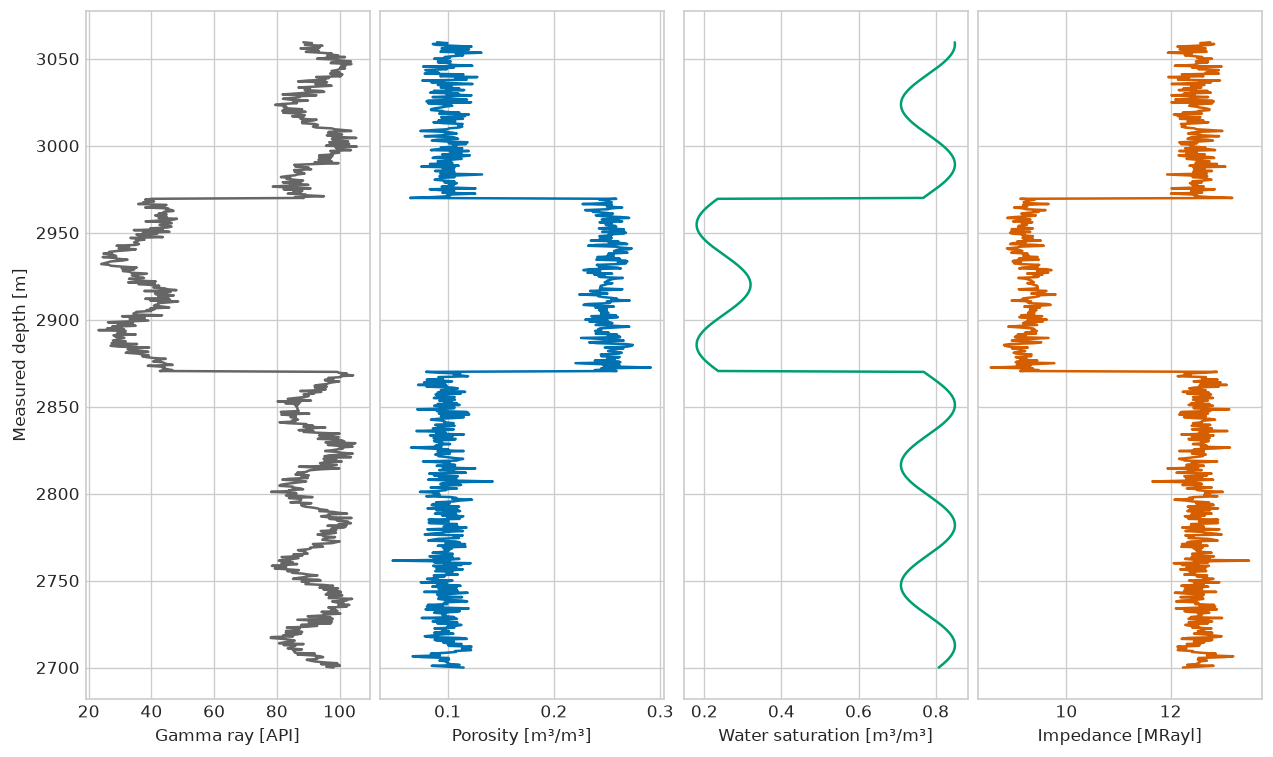

In [10]:
selected_well = well_logs.loc[well_logs["well"].eq("15/9-F-1 C")]
log_figure, log_axes = plt.subplots(
    1,
    4,
    figsize=(10.5, 6.2),
    sharey=True,
    constrained_layout=True,
)
tracks = [
    ("gamma_ray_api", "Gamma ray [API]", "#666666"),
    ("porosity_fraction", "Porosity [m³/m³]", "#0072B2"),
    ("water_saturation_fraction", "Water saturation [m³/m³]", "#009E73"),
    ("impedance_MRayl", "Impedance [MRayl]", "#D55E00"),
]
for axis, (column, label, color) in zip(log_axes, tracks):
    axis.plot(selected_well[column], selected_well["md_m"], color=color)
    axis.set_xlabel(label)
    axis.invert_yaxis()
log_axes[0].set_ylabel("Measured depth [m]")
plt.show()


## 5. NeqSim fluid properties for rock-physics substitution

NeqSim supplies thermodynamically consistent oil, gas, and water
densities at the reservoir pressure and temperature. A complete
rock-physics workflow would calibrate dry-frame moduli and use
Gassmann substitution with laboratory and log data. Here the
NeqSim densities are exposed as an explicit handoff rather than
silently embedded in an empirical velocity transform.


In [11]:
reservoir_fluid = jneqsim.thermo.system.SystemSrkEos(370.65, 260.0)
composition = [
    ("nitrogen", 0.004),
    ("CO2", 0.003),
    ("methane", 0.402),
    ("ethane", 0.076),
    ("propane", 0.080),
    ("i-butane", 0.012),
    ("n-butane", 0.041),
    ("i-pentane", 0.014),
    ("n-pentane", 0.022),
    ("n-hexane", 0.028),
]
for component_name, mole_fraction in composition:
    reservoir_fluid.addComponent(component_name, mole_fraction)
reservoir_fluid.addTBPfraction("C7", 0.16, 0.115, 0.75)
reservoir_fluid.addTBPfraction("C10", 0.158, 0.260, 0.88)
reservoir_fluid.setMixingRule("classic")
reservoir_fluid.setMultiPhaseCheck(True)
TPflash(reservoir_fluid)
reservoir_fluid.initPhysicalProperties()

fluid_density_rows = []
for phase_index in range(reservoir_fluid.getNumberOfPhases()):
    phase = reservoir_fluid.getPhase(phase_index)
    fluid_density_rows.append(
        {
            "phase": str(phase.getPhaseTypeName()),
            "density_kg_m3": phase.getDensity("kg/m3"),
            "viscosity_cP": phase.getViscosity("cP"),
        }
    )
fluid_density_table = pd.DataFrame(fluid_density_rows)
display(fluid_density_table)


,phase,density_kg_m3,viscosity_cP
0,oil,638.277191,0.204877


## 6. Depth conversion, gross rock volume, and STOIIP

The deterministic volume is a screening calculation:

$$N=\frac{GRV\;NTG\;\phi\;(1-S_w)}{B_o}$$

where $N$ is stock-tank oil initially in place, $GRV$ is gross rock
volume, $NTG$ is net-to-gross, $\phi$ is porosity, $S_w$ is water
saturation, and $B_o$ is the oil formation-volume factor. None of
these inputs should be collapsed to one number before uncertainty
and spatial correlation are reviewed.


In [12]:
velocity_m_s = 3400.0
depth_top_m = picked_top_ms * velocity_m_s / 2000.0
depth_base_m = picked_base_ms * velocity_m_s / 2000.0
thickness_m = depth_base_m - depth_top_m
cell_area_m2 = 50.0 * 50.0
gross_rock_volume_m3 = float(thickness_m.sum() * cell_area_m2)
average_ntg = float(
    petrophysical_summary["net_pay_m"].sum()
    / max(petrophysical_summary["gross_interval_m"].sum(), 1.0)
)
average_porosity = well_logs.loc[
    well_logs["pay_flag"],
    "porosity_fraction",
].mean()
average_water_saturation = well_logs.loc[
    well_logs["pay_flag"],
    "water_saturation_fraction",
].mean()
oil_fvf = 1.28
stoiip_sm3 = (
    gross_rock_volume_m3
    * average_ntg
    * average_porosity
    * (1.0 - average_water_saturation)
    / oil_fvf
)
deterministic_volume = pd.DataFrame(
    {
        "quantity": [
            "gross rock volume",
            "net-to-gross",
            "porosity",
            "water saturation",
            "oil FVF",
            "STOIIP",
        ],
        "value": [
            gross_rock_volume_m3,
            average_ntg,
            average_porosity,
            average_water_saturation,
            oil_fvf,
            stoiip_sm3 / 1.0e6,
        ],
        "unit": ["m³", "fraction", "fraction", "fraction", "rm³/Sm³", "MSm³"],
    }
)
display(deterministic_volume)


,quantity,value,unit
0,gross rock volume,2.896800e+08,m³
1,net-to-gross,2.684284e-01,fraction
2,porosity,2.505190e-01,fraction
3,water saturation,2.387127e-01,fraction
4,oil FVF,1.280000e+00,rm³/Sm³
5,STOIIP,1.158580e+01,MSm³


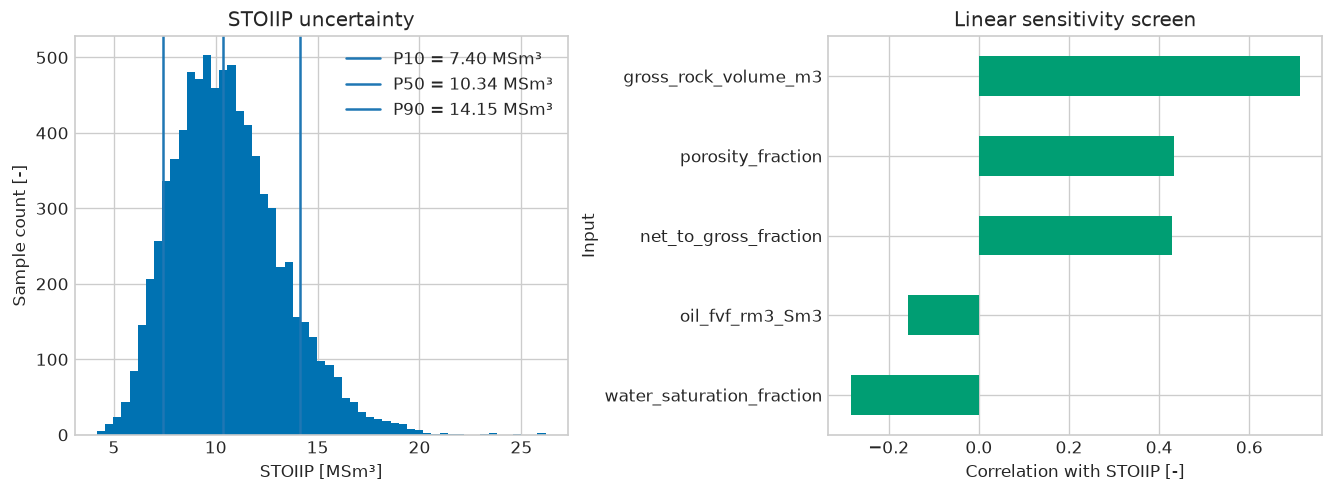

In [13]:
stoiip_samples = vc.calculate_stoiip_distribution(8000)
percentiles = stoiip_samples["stoiip_MSm3"].quantile([0.1, 0.5, 0.9])
sensitivity = stoiip_samples.corr(numeric_only=True)[
    "stoiip_MSm3"
].drop("stoiip_MSm3")
uncertainty_figure, uncertainty_axes = plt.subplots(
    1,
    2,
    figsize=(11.0, 4.0),
    constrained_layout=True,
)
uncertainty_axes[0].hist(
    stoiip_samples["stoiip_MSm3"],
    bins=55,
    color="#0072B2",
)
for probability, value in percentiles.items():
    uncertainty_axes[0].axvline(
        value,
        label=f"P{int(probability * 100)} = {value:.2f} MSm³",
    )
uncertainty_axes[0].set(
    title="STOIIP uncertainty",
    xlabel="STOIIP [MSm³]",
    ylabel="Sample count [-]",
)
uncertainty_axes[0].legend()
sensitivity.sort_values().plot.barh(
    ax=uncertainty_axes[1],
    color="#009E73",
)
uncertainty_axes[1].set(
    title="Linear sensitivity screen",
    xlabel="Correlation with STOIIP [-]",
    ylabel="Input",
)
plt.show()


## 7. Static-model handoff

The handoff carries geometry statistics, petrophysical summaries,
P10/P50/P90 volumes, NeqSim fluid properties, selected data paths,
and explicit limitations. A real project would additionally export
corner-point geometry, facies, porosity, permeability, saturation,
contacts, regions, fault transmissibility multipliers, and
realization identifiers.


In [14]:
seismic_contract_path = vc.write_contract(
    work_dir / "01_geoscience_static_model.json",
    {
        "discipline": "geoscience-and-static-model",
        "data_status": (
            "MEASURED_VOLVE"
            if source.measured_data_loaded
            else "DEMONSTRATION_FALLBACK"
        ),
        "grid_shape": list(cube.shape[:2]),
        "cell_area_m2": cell_area_m2,
        "top_pick_rmse_ms": float(top_rmse_ms),
        "thickness_pick_rmse_ms": float(thickness_rmse_ms),
        "gross_rock_volume_m3": gross_rock_volume_m3,
        "stoiip_percentiles_MSm3": {
            "P10_low": float(percentiles.loc[0.1]),
            "P50": float(percentiles.loc[0.5]),
            "P90_high": float(percentiles.loc[0.9]),
        },
        "fluid_density_records": fluid_density_table.to_dict("records"),
        "limitations": [
            "screening depth conversion",
            "no seismic inversion or calibrated geostatistics",
            "teaching fixture unless Marketplace mode is used",
        ],
    },
    source,
)
print(seismic_contract_path)
print(seismic_contract_path.read_text(encoding="utf-8")[:1400])


/workspace/scratch/e32f838678f8/neqsim-colab-nb01/notebooks/fielddevelopment/volve/work/01_geoscience_static_model.json
{
  "cell_area_m2": 2500.0,
  "data_status": "DEMONSTRATION_FALLBACK",
  "discipline": "geoscience-and-static-model",
  "fluid_density_records": [
    {
      "density_kg_m3": 638.2771909533349,
      "phase": "oil",
      "viscosity_cP": 0.20487701620205578
    }
  ],
  "generated_at_utc": "2026-08-23T07:44:30.654485+00:00",
  "grid_shape": [
    36,
    44
  ],
  "gross_rock_volume_m3": 289680000.0,
  "limitations": [
    "screening depth conversion",
    "no seismic inversion or calibrated geostatistics",
    "teaching fixture unless Marketplace mode is used"
  ],
  "schema_version": "1.0",
  "source": {
    "credential_route": "none",
    "limitation": "Deterministic teaching fixtures are used. Results are not measured Volve values and are not a history match.",
    "marketplace_url": "https://marketplace.databricks.com/details/5c3558ef-315c-44dd-baef-7062ac301f22

## 8. Executable validation and interpretation

The gates check exact synthetic truth, finite arrays, sensible net
pay, normalized composition, positive fluid properties, ordered
uncertainty percentiles, and a readable handoff. Passing these
checks validates the teaching workflow—not the real Volve
interpretation.


In [15]:
checks = {
    "cube is finite": np.isfinite(cube).all(),
    "top pick within one sample RMS": top_rmse_ms < 4.0,
    "thickness pick within one sample RMS": thickness_rmse_ms < 4.0,
    "each well has pay": bool(
        petrophysical_summary["net_pay_m"].gt(0.0).all()
    ),
    "porosity is physical": bool(
        well_logs["porosity_fraction"].between(0.0, 0.5).all()
    ),
    "STOIIP percentiles ordered": bool(
        percentiles.loc[0.1] < percentiles.loc[0.5] < percentiles.loc[0.9]
    ),
    "fluid densities positive": bool(
        fluid_density_table["density_kg_m3"].gt(0.0).all()
    ),
    "handoff exists": seismic_contract_path.is_file(),
}
validation = pd.DataFrame(
    {"check": checks.keys(), "passed": checks.values()}
)
display(validation)
if not validation["passed"].all():
    raise AssertionError(validation.loc[~validation["passed"], "check"].tolist())
print(f"All {len(checks)} geoscience checks passed.")


All 8 geoscience checks passed.


,check,passed
0,cube is finite,True
1,top pick within one sample RMS,True
2,thickness pick within one sample RMS,True
3,each well has pay,True
4,porosity is physical,True
5,STOIIP percentiles ordered,True
6,fluid densities positive,True
7,handoff exists,True


## Engineering interpretation and next notebook

Seismic controls structure, connectivity hypotheses, and gross
volume; wells calibrate depth, facies, porosity, saturation, and
rock physics; NeqSim supplies fluid properties. Notebook 2 converts
the static and fluid evidence into compositional PVT, black-oil
tables, reservoir initialization, history diagnostics, and a
forecast handoff. The uncertainty distribution is preserved rather
than reduced to one deterministic reserves number.
